# Stage 2 — Transformation Design Analysis

**Purpose.** This notebook is exploratory and methodological. It empirically characterizes the
structural, semantic, relational, and temporal properties of the canonical FHIR R4 representation
(**R0**) for the five resource types identified in Stage 1 as central to this experiment
(`Patient`, `Encounter`, `Condition`, `Observation`, `MedicationRequest`), in order to determine
*which* aspects of R0 may be affected by analytics-oriented transformations.

**Explicit scope constraints for this stage:**

- Do **not** construct R1 or R2.
- Do **not** flatten the complete dataset.
- Do **not** remove fields.
- Do **not** benchmark performance.
- Do **not** calculate information-preservation scores.
- Do **not** modify any source files.

All findings below are derived directly from the structures actually observed in the dataset —
not from the FHIR specification in the abstract. Risk language throughout uses *"potential
information-loss risk"*, never a claim that information *is* lost.


## 0. Imports and repository root

In [1]:
import json
import os
import re
import sys
import platform
import random
import statistics
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

def find_repo_root(start: Path) -> Path:
    # Walk upward from `start` until a `.git` directory is found.
    p = start.resolve()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    return start.resolve()

REPO_ROOT = find_repo_root(Path.cwd())
STAGE1_DIR = REPO_ROOT / "results" / "stage1"
RESULTS_DIR = REPO_ROOT / "results" / "stage2"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root  :", REPO_ROOT)
print("Stage 1 results   :", STAGE1_DIR)
print("Stage 2 results   :", RESULTS_DIR)


Repository root  : C:\Users\hmeln\sources\repos\FHIR-Transform
Stage 1 results   : C:\Users\hmeln\sources\repos\FHIR-Transform\results\stage1
Stage 2 results   : C:\Users\hmeln\sources\repos\FHIR-Transform\results\stage2


In [2]:
env_info = {
    "python_version_full": sys.version,
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "system": platform.system(),
    "machine": platform.machine(),
    "pandas_version": pd.__version__,
    "matplotlib_version": matplotlib.__version__,
    "random_seed": RANDOM_SEED,
    "audit_run_timestamp": datetime.now().isoformat(timespec="seconds"),
}
for k, v in env_info.items():
    print(f"{k:22s}: {v}")


python_version_full   : 3.14.6 (main, Jun 23 2026, 15:20:04) [MSC v.1944 64 bit (AMD64)]
python_version        : 3.14.6
platform              : Windows-11-10.0.26200-SP0
system                : Windows
machine               : AMD64
pandas_version        : 3.0.6
matplotlib_version    : 3.11.2
random_seed           : 42
audit_run_timestamp   : 2026-09-26T19:13:41


## 1. Load R0

We reproduce the Stage 1 dataset-discovery logic exactly (same candidate-selection rule) so that
the same dataset directory is chosen, then reload every FHIR resource from every bundle without
altering structure in any way. Resource counts for the five target types are then compared
against the Stage 1 machine-readable summary (`results/stage1/dataset_summary.json`). If any
count differs, execution stops with a explicit discrepancy report rather than continuing on
inconsistent data.

In [3]:
EXCLUDE_DIRS = {".git", ".venv", "venv", "node_modules", "notebooks", "results", ".ipynb_checkpoints", "__pycache__"}
MIN_JSON_FILES_FOR_CANDIDATE = 10
TARGET_PATIENT_COUNT = 100

candidates = []
for dirpath, dirnames, filenames in os.walk(REPO_ROOT):
    dirnames[:] = [d for d in dirnames if d not in EXCLUDE_DIRS]
    json_files_here = [f for f in filenames if f.lower().endswith(".json")]
    if len(json_files_here) >= MIN_JSON_FILES_FOR_CANDIDATE:
        total_size = sum((Path(dirpath) / f).stat().st_size for f in json_files_here)
        candidates.append({"path": Path(dirpath), "n_json_files": len(json_files_here), "total_size_bytes": total_size})

best = min(candidates, key=lambda c: abs(c["n_json_files"] - TARGET_PATIENT_COUNT))
DATASET_DIR = best["path"]
json_files = sorted(DATASET_DIR.glob("*.json"))

print("Selected dataset directory:", DATASET_DIR.relative_to(REPO_ROOT))
print("Number of JSON files      :", len(json_files))

with open(STAGE1_DIR / "dataset_summary.json", encoding="utf-8") as f:
    stage1_summary = json.load(f)

selected_rel = str(DATASET_DIR.relative_to(REPO_ROOT)).replace("\\", "/")
stage1_rel = stage1_summary["dataset_path"].replace("\\", "/")
assert selected_rel == stage1_rel, f"Dataset directory mismatch vs Stage 1: {selected_rel} != {stage1_rel}"
print("Dataset directory matches the Stage 1 selection.")


Selected dataset directory: synthea_sample_data_fhir_latest
Number of JSON files      : 111
Dataset directory matches the Stage 1 selection.


In [4]:
raw_data = {}
parse_errors = []
for fp in json_files:
    try:
        with open(fp, encoding="utf-8") as f:
            raw_data[fp.name] = json.load(f)
    except Exception as e:
        parse_errors.append({"file": fp.name, "error": str(e)})

print(f"Parsed {len(raw_data)} / {len(json_files)} JSON files ({len(parse_errors)} parse errors)")

all_resources = []  # each item: {"file": <filename>, "resource": <raw resource dict, untouched>}
for fname, data in raw_data.items():
    for e in data.get("entry", []):
        res = e.get("resource")
        if res is not None:
            all_resources.append({"file": fname, "resource": res})

print("Total FHIR resources across dataset:", len(all_resources))

TARGET_RESOURCE_TYPES = ["Patient", "Encounter", "Condition", "Observation", "MedicationRequest"]
resources_by_target_type = {
    rt: [r["resource"] for r in all_resources if r["resource"].get("resourceType") == rt]
    for rt in TARGET_RESOURCE_TYPES
}


Parsed 111 / 111 JSON files (0 parse errors)


Total FHIR resources across dataset: 119981


In [5]:
current_counts = {rt: len(resources_by_target_type[rt]) for rt in TARGET_RESOURCE_TYPES}
expected_counts = stage1_summary["target_resource_counts"]

print(f"{'resourceType':<20}{'stage1':>10}{'stage2':>10}{'match':>8}")
mismatches = []
for rt in TARGET_RESOURCE_TYPES:
    match = current_counts[rt] == expected_counts[rt]
    print(f"{rt:<20}{expected_counts[rt]:>10}{current_counts[rt]:>10}{str(match):>8}")
    if not match:
        mismatches.append({"resourceType": rt, "stage1": expected_counts[rt], "stage2": current_counts[rt]})

if mismatches:
    raise RuntimeError(f"Resource count mismatch vs Stage 1 — stopping rather than continuing: {mismatches}")

print("\\nAll target resource counts match Stage 1 exactly. R0 is confirmed reproducible; proceeding.")


resourceType            stage1    stage2   match
Patient                    109       109    True
Encounter                 5635      5635    True
Condition                 3540      3540    True
Observation              46305     46305    True
MedicationRequest         3858      3858    True
\nAll target resource counts match Stage 1 exactly. R0 is confirmed reproducible; proceeding.


## 2 & 3. Detailed structural analysis and nested-structure complexity

For every target resource type we recursively walk every instance actually present in the
dataset and record, for every distinct field *path* encountered (dot-notation, with array
indices collapsed to `[]`, e.g. `code.coding[].system`):

- **physical structure** — the raw JSON shape actually observed: `scalar`, `object`,
  `array_of_scalars`, `array_of_objects`;
- **semantic category** — an empirically-driven classification of what the shape *represents*:
  `reference`, `coded_concept` (CodeableConcept-shaped: has a `coding` array), `coding` (a bare
  `Coding`: `system`+`code` without a wrapping `coding` array), `quantity` (numeric `value` plus
  `unit`/`system`/`code`), `identifier` (string `value` plus `system`, FHIR `Identifier` shape),
  `temporal` (ISO date/datetime string, or a `Period`-shaped object with `start`/`end`),
  `provenance_or_context`, `plain_object`, `plain_array`, `scalar`, `empty_array`.

Physical structure and semantic category are recorded as **separate columns** — a field can be
physically an `object` while being semantically a `reference`, a `quantity`, or a `coded_concept`
at the same time; we do not collapse that distinction.

Nesting depth is defined as: a scalar has depth 0; a non-empty object has depth
`1 + max(depth of its values)`; a list has the depth of its richest element (an array does not,
by itself, add a depth level — only the objects nested inside it do). This rule is applied
per-resource-instance, then aggregated (max, mean) per resource type.

In [6]:
DATE_RE = re.compile(r"^\d{4}-\d{2}-\d{2}$")
DATETIME_RE = re.compile(r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}")

def looks_temporal_string(value):
    return bool(DATE_RE.match(value) or DATETIME_RE.match(value))

def physical_structure(value):
    if isinstance(value, dict):
        return "object"
    if isinstance(value, list):
        if len(value) == 0:
            return "array_of_scalars"
        return "array_of_objects" if isinstance(value[0], dict) else "array_of_scalars"
    return "scalar"

def classify_semantic(key, value):
    # Semantic role of a field, classified from its *actual observed shape*, not the FHIR spec.
    if isinstance(value, dict):
        keys = set(value.keys())
        if "reference" in keys:
            return "reference"
        if "coding" in keys:
            return "coded_concept"
        if {"system", "code"}.issubset(keys) and not ({"value", "unit"} & keys):
            return "coding"
        if "value" in keys and isinstance(value.get("value"), (int, float)) and ({"unit", "code", "system"} & keys):
            return "quantity"
        if "value" in keys and isinstance(value.get("value"), str) and "system" in keys:
            return "identifier"
        if "start" in keys or "end" in keys:
            return "temporal"
        if key in ("meta", "identifier"):
            return "provenance_or_context"
        return "plain_object"
    if isinstance(value, list):
        return "empty_array" if len(value) == 0 else "plain_array"
    if isinstance(value, str) and looks_temporal_string(value):
        return "temporal"
    return "scalar"

def calc_depth(obj):
    if isinstance(obj, dict):
        if not obj:
            return 1
        return 1 + max((calc_depth(v) for v in obj.values()), default=0)
    if isinstance(obj, list):
        if not obj:
            return 0
        return max((calc_depth(v) for v in obj), default=0)
    return 0

def walk_resource(obj, prefix, path_stats, seen_in_this_resource):
    if isinstance(obj, dict):
        for k, v in obj.items():
            path = f"{prefix}.{k}" if prefix else k
            seen_in_this_resource.add(path)
            stat = path_stats.setdefault(path, {"physical": Counter(), "semantic": Counter(), "example": None})
            stat["physical"][physical_structure(v)] += 1
            stat["semantic"][classify_semantic(k, v)] += 1
            if stat["example"] is None:
                try:
                    stat["example"] = json.dumps(v, default=str)[:160]
                except Exception:
                    stat["example"] = str(v)[:160]
            walk_resource(v, path, path_stats, seen_in_this_resource)
    elif isinstance(obj, list):
        for item in obj:
            walk_resource(item, f"{prefix}[]", path_stats, seen_in_this_resource)
    # scalars: leaf, nothing further to record

def analyze_resource_type(rt, resources):
    path_stats = {}
    resource_presence = Counter()
    depths = []
    for res in resources:
        seen = set()
        depths.append(calc_depth(res))
        walk_resource(res, "", path_stats, seen)
        resource_presence.update(seen)
    n = len(resources)
    rows = []
    for path, stat in path_stats.items():
        physical = stat["physical"].most_common(1)[0][0]
        semantic = stat["semantic"].most_common(1)[0][0]
        rows.append({
            "resourceType": rt,
            "field_path": path,
            "physical_structure": physical,
            "semantic_category": semantic,
            "n_resources_with_field": resource_presence[path],
            "pct_of_resources": round(resource_presence[path] / n * 100, 2) if n else None,
            "n_element_occurrences": sum(stat["physical"].values()),
            "example_value": stat["example"],
        })
    df = pd.DataFrame(rows).sort_values(["pct_of_resources"], ascending=False).reset_index(drop=True)
    return df, depths

structural_frames = []
depths_by_type = {}
for rt in TARGET_RESOURCE_TYPES:
    df_rt, depths = analyze_resource_type(rt, resources_by_target_type[rt])
    structural_frames.append(df_rt)
    depths_by_type[rt] = depths

structural_inventory_df = pd.concat(structural_frames, ignore_index=True)
print("Distinct field paths discovered per resource type:")
print(structural_inventory_df.groupby("resourceType").size())
structural_inventory_df.head(15)


Distinct field paths discovered per resource type:
resourceType
Condition            30
Encounter            56
MedicationRequest    60
Observation          53
Patient              71
dtype: int64


,resourceType,field_path,physical_structure,semantic_category,n_resources_with_field,pct_of_resources,n_element_occurrences,example_value
0,Patient,resourceType,scalar,scalar,109,100.0,109,"""Patient"""
1,Patient,id,scalar,scalar,109,100.0,109,"""37549f60-b5a3-69cd-dea6-5a71c4bc23cf"""
2,Patient,meta,object,provenance_or_context,109,100.0,109,"{""profile"": [""http://hl7.org/fhir/us/core/Stru..."
3,Patient,meta.profile,array_of_scalars,plain_array,109,100.0,109,"[""http://hl7.org/fhir/us/core/StructureDefinit..."
4,Patient,text,object,plain_object,109,100.0,109,"{""status"": ""generated"", ""div"": ""<div xmlns=\""h..."
5,Patient,text.status,scalar,scalar,109,100.0,109,"""generated"""
6,Patient,text.div,scalar,scalar,109,100.0,109,"""<div xmlns=\""http://www.w3.org/1999/xhtml\"">G..."
7,Patient,extension,array_of_objects,plain_array,109,100.0,109,"[{""url"": ""http://hl7.org/fhir/us/core/Structur..."
8,Patient,extension[].url,scalar,scalar,109,100.0,763,"""http://hl7.org/fhir/us/core/StructureDefiniti..."
9,Patient,extension[].extension,array_of_objects,plain_array,109,100.0,218,"[{""url"": ""ombCategory"", ""valueCoding"": {""syste..."


In [7]:
complexity_rows = []
for rt in TARGET_RESOURCE_TYPES:
    sub = structural_inventory_df[structural_inventory_df["resourceType"] == rt]
    depths = depths_by_type[rt]
    complexity_rows.append({
        "resourceType": rt,
        "n_instances": len(resources_by_target_type[rt]),
        "n_distinct_fields": len(sub),
        "n_nested_structures": int(sub["physical_structure"].isin(["object", "array_of_objects"]).sum()),
        "n_arrays": int(sub["physical_structure"].isin(["array_of_scalars", "array_of_objects"]).sum()),
        "n_references": int((sub["semantic_category"] == "reference").sum()),
        "max_nesting_depth": max(depths) if depths else None,
        "avg_nesting_depth": round(statistics.mean(depths), 2) if depths else None,
    })

resource_complexity_df = pd.DataFrame(complexity_rows)
resource_complexity_df


,resourceType,n_instances,n_distinct_fields,n_nested_structures,n_arrays,n_references,max_nesting_depth,avg_nesting_depth
0,Patient,109,71,19,17,0,4,4.00
1,Encounter,5635,56,20,11,4,4,4.00
2,Condition,3540,30,11,6,2,3,3.00
3,Observation,46305,53,16,8,2,4,3.05
4,MedicationRequest,3858,60,21,12,4,5,3.69


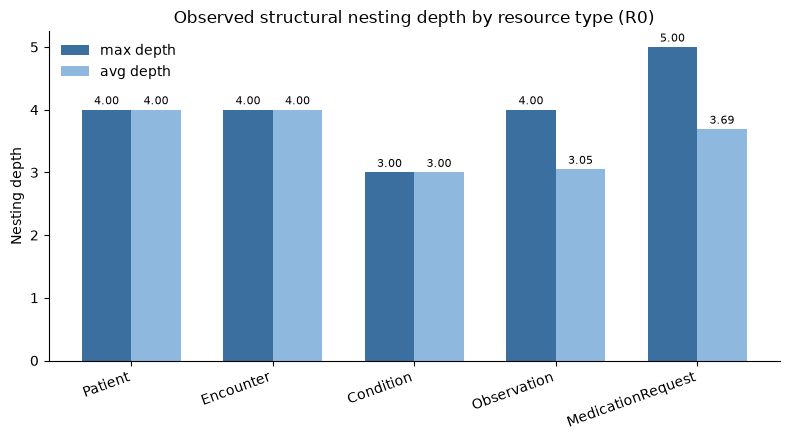

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(resource_complexity_df))
width = 0.35
bars_max = ax.bar(x - width / 2, resource_complexity_df["max_nesting_depth"], width,
                   label="max depth", color="#3B6FA0")
bars_avg = ax.bar(x + width / 2, resource_complexity_df["avg_nesting_depth"], width,
                   label="avg depth", color="#8FB8DE")
ax.set_xticks(x)
ax.set_xticklabels(resource_complexity_df["resourceType"], rotation=20, ha="right")
ax.set_ylabel("Nesting depth")
ax.set_title("Observed structural nesting depth by resource type (R0)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
for bars in (bars_max, bars_avg):
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
plt.tight_layout()
plt.show()


## 4. Observation polymorphism analysis

`Observation.value[x]` is a FHIR polymorphic element: exactly one of several typed fields
(`valueQuantity`, `valueCodeableConcept`, `valueString`, ...) may be present. We detect *whichever
representations actually occur* by pattern-matching top-level keys of the form `value<Type>`,
and separately characterize `component[]` (itself containing nested `value[x]` per component,
used for panel-style observations such as blood pressure).

In [9]:
observations = resources_by_target_type["Observation"]
n_obs = len(observations)
VALUE_X_RE = re.compile(r"^value[A-Z]")

value_x_counter = Counter()
value_x_example = {}
value_x_depth = {}
value_x_unit_hits = Counter()
value_x_code_hits = Counter()
n_with_component = 0
component_count_dist = Counter()
component_value_x_counter = Counter()

for res in observations:
    for k in res.keys():
        if not VALUE_X_RE.match(k):
            continue
        v = res[k]
        value_x_counter[k] += 1
        if k not in value_x_example:
            value_x_example[k] = json.dumps(v, default=str)[:200]
            value_x_depth[k] = calc_depth(v)
        if isinstance(v, dict):
            if "unit" in v or "code" in v:
                value_x_unit_hits[k] += 1
            if "coding" in v:
                value_x_code_hits[k] += 1
    comps = res.get("component")
    if comps:
        n_with_component += 1
        component_count_dist[len(comps)] += 1
        for comp in comps:
            for k, v in comp.items():
                if VALUE_X_RE.match(k):
                    component_value_x_counter[k] += 1

print(f"Observations with a top-level value[x]: {sum(value_x_counter.values())} occurrences across {len(value_x_counter)} representations")
print(f"Observations with component[]          : {n_with_component} / {n_obs} ({round(n_with_component / n_obs * 100, 2)}%)")
print("Component-count distribution           :", dict(sorted(component_count_dist.items())))
print("value[x] representations seen inside component[]:", dict(component_value_x_counter))


Observations with a top-level value[x]: 44038 occurrences across 3 representations
Observations with component[]          : 2267 / 46305 (4.9%)
Component-count distribution           : {1: 1, 2: 1347, 3: 12, 21: 907}
value[x] representations seen inside component[]: {'valueQuantity': 4536, 'valueCodeableConcept': 16326, 'valueString': 916}


In [10]:
polymorphism_rows = []
for k, count in value_x_counter.items():
    polymorphism_rows.append({
        "category": "top_level_value_representation",
        "representation": k,
        "occurrence_count": count,
        "pct_of_observations": round(count / n_obs * 100, 2) if n_obs else None,
        "nesting_depth": value_x_depth.get(k),
        "pct_with_units": round(value_x_unit_hits[k] / count * 100, 2) if count else None,
        "pct_with_codes": round(value_x_code_hits[k] / count * 100, 2) if count else None,
        "example_structure": value_x_example.get(k),
    })

polymorphism_rows.append({
    "category": "compound_representation",
    "representation": "component[]",
    "occurrence_count": n_with_component,
    "pct_of_observations": round(n_with_component / n_obs * 100, 2) if n_obs else None,
    "nesting_depth": max((calc_depth(res.get("component")) for res in observations if res.get("component")), default=None),
    "pct_with_units": None,
    "pct_with_codes": None,
    "example_structure": json.dumps(next(res["component"] for res in observations if res.get("component"))[:2], default=str)[:300],
})

for cnt, freq in sorted(component_count_dist.items()):
    polymorphism_rows.append({
        "category": "component_count_distribution",
        "representation": f"component_count={cnt}",
        "occurrence_count": freq,
        "pct_of_observations": round(freq / n_obs * 100, 2) if n_obs else None,
        "nesting_depth": None, "pct_with_units": None, "pct_with_codes": None, "example_structure": None,
    })

observation_polymorphism_df = pd.DataFrame(polymorphism_rows)
observation_polymorphism_df


,category,representation,occurrence_count,pct_of_observations,nesting_depth,pct_with_units,pct_with_codes,example_structure
0,top_level_value_representation,valueQuantity,36082,77.92,1.0,99.99,0.0,"{""value"": 5.85, ""unit"": ""%"", ""system"": ""http:/..."
1,top_level_value_representation,valueCodeableConcept,7896,17.05,2.0,0.00,100.0,"{""coding"": [{""system"": ""http://snomed.info/sct..."
2,top_level_value_representation,valueString,60,0.13,0.0,0.00,0.0,"""Greater than 100,000 colony forming units per..."
3,compound_representation,component[],2267,4.90,3.0,NaN,NaN,"[{""code"": {""coding"": [{""system"": ""http://loinc..."
4,component_count_distribution,component_count=1,1,0.00,NaN,NaN,NaN,NaN
5,component_count_distribution,component_count=2,1347,2.91,NaN,NaN,NaN,NaN
6,component_count_distribution,component_count=3,12,0.03,NaN,NaN,NaN,NaN
7,component_count_distribution,component_count=21,907,1.96,NaN,NaN,NaN,NaN


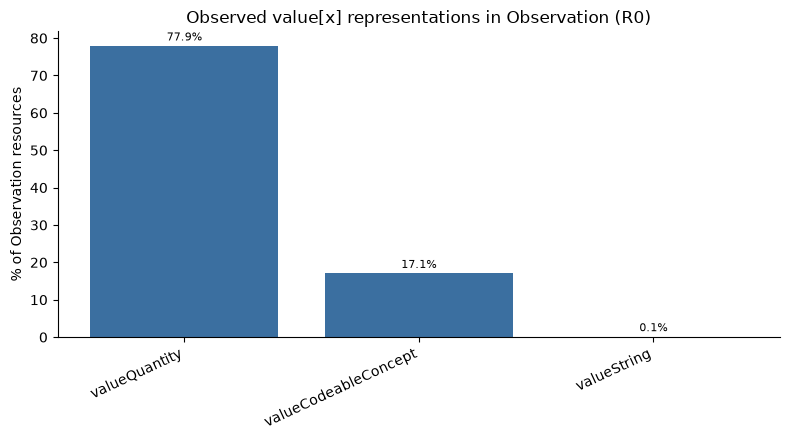

Distinct value/component representations observed in this dataset: 4


In [11]:
top_level = observation_polymorphism_df[observation_polymorphism_df["category"] == "top_level_value_representation"]
fig, ax = plt.subplots(figsize=(8, 4.5))
order = top_level.sort_values("occurrence_count", ascending=False)
bars = ax.bar(order["representation"], order["pct_of_observations"], color="#3B6FA0")
ax.set_ylabel("% of Observation resources")
ax.set_title("Observed value[x] representations in Observation (R0)")
ax.spines[["top", "right"]].set_visible(False)
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=8)
plt.tight_layout()
plt.show()

n_representations = len(top_level) + 1  # + component[]
print(f"Distinct value/component representations observed in this dataset: {n_representations}")


## 5. Coded clinical concepts

For every field path classified as a `coded_concept` (CodeableConcept-shaped: has a `coding`
array) in `Condition`, `Observation`, `MedicationRequest`, and `Encounter`, we inspect every
actual instance to determine the coding systems in use, how often more than one coding is
attached to the same concept, and how often free-text (`text`) or human-readable `display` is
present alongside the machine code.

In [12]:
def get_values_at_path(obj, path):
    # Resolve a dot-notation path (with '[]' array markers) against a resource instance,
    # returning every matching sub-value (there may be more than one under an array).
    segments = path.split(".")
    current = [obj]
    for seg in segments:
        is_array = seg.endswith("[]")
        key = seg[:-2] if is_array else seg
        nxt = []
        for item in current:
            if not isinstance(item, dict) or key not in item:
                continue
            val = item[key]
            if is_array:
                if isinstance(val, list):
                    nxt.extend(val)
            else:
                nxt.append(val)
        current = nxt
    return current

CODING_RESOURCE_TYPES = ["Condition", "Observation", "MedicationRequest", "Encounter"]
coding_rows = []
for rt in CODING_RESOURCE_TYPES:
    concept_paths = structural_inventory_df[
        (structural_inventory_df["resourceType"] == rt)
        & (structural_inventory_df["semantic_category"] == "coded_concept")
    ]["field_path"].tolist()
    for path in concept_paths:
        concepts = []
        for res in resources_by_target_type[rt]:
            concepts.extend(get_values_at_path(res, path))
        n_concepts = len(concepts)
        if n_concepts == 0:
            continue
        n_with_text = sum(1 for c in concepts if isinstance(c, dict) and c.get("text"))
        n_multi_coding = sum(1 for c in concepts if isinstance(c, dict) and isinstance(c.get("coding"), list) and len(c["coding"]) > 1)
        systems = Counter()
        n_with_display = 0
        n_codings_total = 0
        code_system_pairs = set()
        for c in concepts:
            for cd in (c.get("coding", []) if isinstance(c, dict) else []):
                n_codings_total += 1
                sysname = cd.get("system")
                systems[sysname] += 1
                if cd.get("display"):
                    n_with_display += 1
                code_system_pairs.add((sysname, cd.get("code")))
        coding_rows.append({
            "resourceType": rt,
            "concept_path": path,
            "n_coded_concepts": n_concepts,
            "coding_systems": "; ".join(f"{s} (n={c})" for s, c in systems.most_common()),
            "n_distinct_coding_systems": len([s for s in systems if s]),
            "n_multi_coding_concepts": n_multi_coding,
            "pct_multi_coding": round(n_multi_coding / n_concepts * 100, 2),
            "pct_with_text": round(n_with_text / n_concepts * 100, 2),
            "n_codings_total": n_codings_total,
            "pct_codings_with_display": round(n_with_display / n_codings_total * 100, 2) if n_codings_total else None,
            "n_distinct_code_system_combinations": len(code_system_pairs),
        })

coding_systems_df = pd.DataFrame(coding_rows).sort_values(["resourceType", "concept_path"]).reset_index(drop=True)
coding_systems_df


,resourceType,concept_path,n_coded_concepts,coding_systems,n_distinct_coding_systems,n_multi_coding_concepts,pct_multi_coding,pct_with_text,n_codings_total,pct_codings_with_display,n_distinct_code_system_combinations
0,Condition,clinicalStatus,3540,http://terminology.hl7.org/CodeSystem/conditio...,1,0,0.00,0.0,3540,0.0,2
1,Condition,code,3540,http://snomed.info/sct (n=3540),1,0,0.00,100.0,3540,100.0,186
2,Condition,verificationStatus,3540,http://terminology.hl7.org/CodeSystem/conditio...,1,0,0.00,0.0,3540,0.0,1
3,Encounter,hospitalization.dischargeDisposition,15,http://www.nubc.org/patient-discharge (n=15),1,0,0.00,100.0,15,100.0,2
4,MedicationRequest,dosageInstruction[].doseAndRate[].type,1332,http://terminology.hl7.org/CodeSystem/dose-rat...,1,0,0.00,0.0,1332,100.0,1
5,MedicationRequest,medicationCodeableConcept,2832,http://www.nlm.nih.gov/research/umls/rxnorm (n...,1,0,0.00,100.0,2832,100.0,108
6,Observation,code,46305,http://loinc.org (n=46611); http://snomed.info...,2,397,0.86,100.0,46702,100.0,223
7,Observation,component[].code,21778,http://loinc.org (n=21778),1,0,0.00,100.0,21778,100.0,29
8,Observation,component[].valueCodeableConcept,16326,http://loinc.org (n=16326),1,0,0.00,100.0,16326,100.0,39
9,Observation,valueCodeableConcept,7896,http://snomed.info/sct (n=7611); http://loinc....,2,0,0.00,100.0,7896,100.0,68


In [13]:
overall_concepts = coding_systems_df["n_coded_concepts"].sum()
overall_multi = coding_systems_df["n_multi_coding_concepts"].sum()
overall_multi_coding_pct = round(overall_multi / overall_concepts * 100, 2) if overall_concepts else 0.0
overall_text_pct = round((coding_systems_df["n_coded_concepts"] * coding_systems_df["pct_with_text"] / 100).sum() / overall_concepts * 100, 2)
overall_display_pct = round(
    (coding_systems_df["n_codings_total"] * coding_systems_df["pct_codings_with_display"].fillna(0) / 100).sum()
    / coding_systems_df["n_codings_total"].sum() * 100, 2
)

print(f"Coded concepts inspected across the 4 resource types : {overall_concepts}")
print(f"Concepts carrying >1 coding (alternative terminologies): {overall_multi} ({overall_multi_coding_pct}%)")
print(f"Concepts carrying free-text 'text'                    : {overall_text_pct}%")
print(f"Individual codings carrying human-readable 'display'  : {overall_display_pct}%")
print()
print("Reducing a CodeableConcept to a single 'code' column would, for the fraction of concepts")
print("with multiple codings, discard the alternative coding system(s) entirely (irreversibly,")
print("since the omitted (system, code) pairs are not derivable from the retained one); it would")
print("also discard 'text' and 'display' wherever present, since neither is stored in 'code' alone.")


Coded concepts inspected across the 4 resource types : 107104
Concepts carrying >1 coding (alternative terminologies): 397 (0.37%)
Concepts carrying free-text 'text'                    : 92.15%
Individual codings carrying human-readable 'display'  : 93.41%

Reducing a CodeableConcept to a single 'code' column would, for the fraction of concepts
with multiple codings, discard the alternative coding system(s) entirely (irreversibly,
since the omitted (system, code) pairs are not derivable from the retained one); it would
also discard 'text' and 'display' wherever present, since neither is stored in 'code' alone.


## 6. Relationship topology

Using the reference-resolution logic from Stage 1 (URN/relative/conditional-identifier
resolution against an id index built from *all* resources in the dataset, not only the five
target types), we build a logical relationship graph restricted to edges whose source **and**
target are both among the five target resource types, then quantify cardinality per edge type.

In [14]:
id_to_type = {}
for r in all_resources:
    rid = r["resource"].get("id")
    rt = r["resource"].get("resourceType")
    if rid is not None:
        id_to_type[rid] = rt

identifier_index = {}
for r in all_resources:
    res = r["resource"]
    rt = res.get("resourceType")
    for ident in res.get("identifier", []) or []:
        system = ident.get("system")
        value = ident.get("value")
        if system is not None and value is not None:
            identifier_index[(system, value)] = rt

def parse_reference(ref):
    if ref.startswith("urn:uuid:"):
        return "urn:uuid", ref[len("urn:uuid:"):]
    m = re.match(r"^([A-Za-z]+)\?identifier=([^|]+)\|(.+)$", ref)
    if m:
        return "conditional-identifier", m.groups()
    m = re.match(r"^([A-Za-z]+)/(.+)$", ref)
    if m:
        return "relative", m.groups()
    return "other", ref

def resolve_ref(ref):
    kind, parsed = parse_reference(ref)
    if kind == "urn:uuid":
        return id_to_type.get(parsed), parsed
    if kind == "conditional-identifier":
        _, system, value = parsed
        return identifier_index.get((system, value)), f"{system}|{value}"
    if kind == "relative":
        _, target_id = parsed
        return id_to_type.get(target_id), target_id
    return None, ref

edge_records = []
for rt in TARGET_RESOURCE_TYPES:
    for res in resources_by_target_type[rt]:
        src_id = res.get("id")
        for field, value in res.items():
            cands = []
            if isinstance(value, dict) and "reference" in value:
                cands.append(value)
            elif isinstance(value, list):
                cands.extend(v for v in value if isinstance(v, dict) and "reference" in v)
            for cand in cands:
                ref = cand.get("reference")
                if not isinstance(ref, str):
                    continue
                resolved_type, target_id = resolve_ref(ref)
                if resolved_type in TARGET_RESOURCE_TYPES:
                    edge_records.append({
                        "source_resourceType": rt, "source_id": src_id, "reference_field": field,
                        "target_resourceType": resolved_type, "target_id": target_id,
                    })

edges_df = pd.DataFrame(edge_records)
print("Edges among the five target resource types:", len(edges_df))
edges_df.groupby(["source_resourceType", "reference_field", "target_resourceType"]).size()


Edges among the five target resource types: 115774


source_resourceType  reference_field  target_resourceType
Condition            encounter        Encounter               3540
                     subject          Patient                 3540
Encounter            subject          Patient                 5635
MedicationRequest    encounter        Encounter               3858
                     reasonReference  Condition               2733
                     subject          Patient                 3858
Observation          encounter        Encounter              46305
                     subject          Patient                46305
dtype: int64

In [15]:
topology_rows = []
for (src, field, tgt), grp in edges_df.groupby(["source_resourceType", "reference_field", "target_resourceType"]):
    n_edges = len(grp)
    n_src = grp["source_id"].nunique()
    n_tgt = grp["target_id"].nunique()
    src_per_tgt = grp.groupby("target_id")["source_id"].nunique()
    tgt_per_src = grp.groupby("source_id")["target_id"].nunique()
    max_src_per_tgt = int(src_per_tgt.max())
    max_tgt_per_src = int(tgt_per_src.max())
    if max_src_per_tgt > 1 and max_tgt_per_src == 1:
        cardinality = "many source -> one target"
    elif max_tgt_per_src > 1 and max_src_per_tgt == 1:
        cardinality = "one source -> many targets"
    elif max_src_per_tgt == 1 and max_tgt_per_src == 1:
        cardinality = "one-to-one (observed)"
    else:
        cardinality = "many-to-many"
    n_source_total = len(resources_by_target_type[src])
    topology_rows.append({
        "source_resourceType": src, "reference_field": field, "target_resourceType": tgt,
        "n_edges": n_edges,
        "n_unique_source_resources": n_src,
        "n_unique_target_resources": n_tgt,
        "pct_source_resources_covered": round(n_src / n_source_total * 100, 2) if n_source_total else None,
        "max_sources_per_target": max_src_per_tgt,
        "max_targets_per_source": max_tgt_per_src,
        "cardinality": cardinality,
    })

relationship_topology_df = pd.DataFrame(topology_rows).sort_values(["source_resourceType", "target_resourceType"]).reset_index(drop=True)
relationship_topology_df


,source_resourceType,reference_field,target_resourceType,n_edges,n_unique_source_resources,n_unique_target_resources,pct_source_resources_covered,max_sources_per_target,max_targets_per_source,cardinality
0,Condition,encounter,Encounter,3540,3540,2325,100.00,7,1,many source -> one target
1,Condition,subject,Patient,3540,3540,109,100.00,273,1,many source -> one target
2,Encounter,subject,Patient,5635,5635,109,100.00,565,1,many source -> one target
3,MedicationRequest,reasonReference,Condition,2733,2733,231,70.84,381,1,many source -> one target
4,MedicationRequest,encounter,Encounter,3858,3858,2233,100.00,36,1,many source -> one target
5,MedicationRequest,subject,Patient,3858,3858,106,100.00,1113,1,many source -> one target
6,Observation,encounter,Encounter,46305,46305,2546,100.00,684,1,many source -> one target
7,Observation,subject,Patient,46305,46305,109,100.00,9610,1,many source -> one target


In [16]:
mr_condition_row = relationship_topology_df[
    (relationship_topology_df["source_resourceType"] == "MedicationRequest")
    & (relationship_topology_df["target_resourceType"] == "Condition")
]
if len(mr_condition_row):
    r = mr_condition_row.iloc[0]
    print(f"MedicationRequest -> Condition (reasonReference) covers {r['pct_source_resources_covered']}% of "
          f"MedicationRequest resources ({r['n_unique_source_resources']}/{len(resources_by_target_type['MedicationRequest'])}).")
    print("For the remaining MedicationRequests, no direct reference to a Condition exists in R0 — any")
    print("medication-condition association for those records is only reconstructable indirectly (e.g. via")
    print("a shared Encounter or temporal proximity), which is a candidate high-risk path under flattening.")

print()
n_enc_with_cond = edges_df[(edges_df.source_resourceType == "Condition") & (edges_df.reference_field == "encounter")]["target_id"].nunique()
n_enc_with_obs = edges_df[(edges_df.source_resourceType == "Observation") & (edges_df.reference_field == "encounter")]["target_id"].nunique()
n_enc_total = len(resources_by_target_type["Encounter"])
print(f"Encounters linked to >=1 Condition : {n_enc_with_cond} / {n_enc_total}")
print(f"Encounters linked to >=1 Observation: {n_enc_with_obs} / {n_enc_total}")
print("There is no direct Condition<->Observation reference field in R0; any such relationship must be")
print("reconstructed indirectly via a shared Encounter (or via Patient + temporal proximity), which is a")
print("path that becomes difficult to reconstruct if the 'encounter' reference were dropped or replaced")
print("with a bare id disconnected from a relationship table.")


MedicationRequest -> Condition (reasonReference) covers 70.84% of MedicationRequest resources (2733/3858).
For the remaining MedicationRequests, no direct reference to a Condition exists in R0 — any
medication-condition association for those records is only reconstructable indirectly (e.g. via
a shared Encounter or temporal proximity), which is a candidate high-risk path under flattening.

Encounters linked to >=1 Condition : 2325 / 5635
Encounters linked to >=1 Observation: 2546 / 5635
There is no direct Condition<->Observation reference field in R0; any such relationship must be
reconstructed indirectly via a shared Encounter (or via Patient + temporal proximity), which is a
path that becomes difficult to reconstruct if the 'encounter' reference were dropped or replaced
with a bare id disconnected from a relationship table.


## 7. Temporal dependency analysis

We combine the Stage 1 temporal-field inventory with empirical cross-resource checks: do the
temporal fields of related resources actually align the way their names suggest? This grounds
the "distinct temporal semantics" claim in measured evidence rather than field-name inspection
alone.

In [17]:
def parse_dt(s):
    if not s:
        return None
    try:
        return datetime.fromisoformat(s)
    except Exception:
        return None

encounter_by_id = {e["id"]: e for e in resources_by_target_type["Encounter"] if e.get("id")}
condition_by_id = {c["id"]: c for c in resources_by_target_type["Condition"] if c.get("id")}
encounter_period = {
    eid: (parse_dt((e.get("period") or {}).get("start")), parse_dt((e.get("period") or {}).get("end")))
    for eid, e in encounter_by_id.items()
}

def linked_encounter_id(res):
    enc = res.get("encounter")
    if isinstance(enc, dict) and isinstance(enc.get("reference"), str):
        _, eid = resolve_ref(enc["reference"])
        return eid
    return None

# (a) Observation.effectiveDateTime within its linked Encounter.period
obs_within = obs_total = 0
for res in observations:
    eid = linked_encounter_id(res)
    dt = parse_dt(res.get("effectiveDateTime"))
    if dt is not None and eid in encounter_period:
        start, end = encounter_period[eid]
        if start is not None and end is not None:
            obs_total += 1
            if start <= dt <= end:
                obs_within += 1
pct_obs_within_encounter = round(obs_within / obs_total * 100, 2) if obs_total else None

# (b) Condition.onsetDateTime relative to its linked Encounter.period.end
cond_onset_ok = cond_total = 0
for res in resources_by_target_type["Condition"]:
    eid = linked_encounter_id(res)
    dt = parse_dt(res.get("onsetDateTime"))
    if dt is not None and eid in encounter_period:
        _, end = encounter_period[eid]
        if end is not None:
            cond_total += 1
            if dt <= end:
                cond_onset_ok += 1
pct_cond_onset_before_encounter_end = round(cond_onset_ok / cond_total * 100, 2) if cond_total else None

# (c) Condition.onsetDateTime vs recordedDate ordering (clinical onset should not be after data-entry time)
cond_onset_le_recorded = cond_pairs = 0
for res in resources_by_target_type["Condition"]:
    onset = parse_dt(res.get("onsetDateTime"))
    recorded = parse_dt(res.get("recordedDate"))
    if onset is not None and recorded is not None:
        cond_pairs += 1
        if onset <= recorded:
            cond_onset_le_recorded += 1
pct_onset_le_recorded = round(cond_onset_le_recorded / cond_pairs * 100, 2) if cond_pairs else None

# (d) MedicationRequest.authoredOn vs onsetDateTime of the Condition it names as reasonReference
mr_after_condition = mr_total = 0
for res in resources_by_target_type["MedicationRequest"]:
    authored = parse_dt(res.get("authoredOn"))
    for rr in (res.get("reasonReference") or []):
        ref = rr.get("reference") if isinstance(rr, dict) else None
        if not ref:
            continue
        resolved_type, cond_id = resolve_ref(ref)
        if resolved_type != "Condition":
            continue
        cond = condition_by_id.get(cond_id)
        if not cond:
            continue
        onset = parse_dt(cond.get("onsetDateTime"))
        if authored is not None and onset is not None:
            mr_total += 1
            if authored >= onset:
                mr_after_condition += 1
pct_mr_after_condition_onset = round(mr_after_condition / mr_total * 100, 2) if mr_total else None

print(f"Observation.effectiveDateTime within linked Encounter.period : {obs_within}/{obs_total} ({pct_obs_within_encounter}%)")
print(f"Condition.onsetDateTime <= linked Encounter.period.end        : {cond_onset_ok}/{cond_total} ({pct_cond_onset_before_encounter_end}%)")
print(f"Condition.onsetDateTime <= Condition.recordedDate              : {cond_onset_le_recorded}/{cond_pairs} ({pct_onset_le_recorded}%)")
print(f"MedicationRequest.authoredOn >= referenced Condition.onsetDateTime: {mr_after_condition}/{mr_total} ({pct_mr_after_condition_onset}%)")


Observation.effectiveDateTime within linked Encounter.period : 43754/46305 (94.49%)
Condition.onsetDateTime <= linked Encounter.period.end        : 3190/3540 (90.11%)
Condition.onsetDateTime <= Condition.recordedDate              : 3540/3540 (100.0%)
MedicationRequest.authoredOn >= referenced Condition.onsetDateTime: 2733/2733 (100.0%)


In [18]:
FIELD_SEMANTICS = {
    ("Condition", "onsetDateTime"): "clinical onset — when the condition is believed to have begun",
    ("Condition", "recordedDate"): "documentation time — when the condition was entered into the record",
    ("Condition", "abatementDateTime"): "clinical resolution/abatement time",
    ("Encounter", "period.start"): "encounter start (wall-clock)",
    ("Encounter", "period.end"): "encounter end (wall-clock)",
    ("MedicationRequest", "authoredOn"): "prescription authoring time",
    ("Observation", "effectiveDateTime"): "clinical observation/measurement time",
    ("Observation", "issued"): "result issuance / system availability timestamp",
    ("Patient", "birthDate"): "date of birth (date-only precision)",
    ("Patient", "deceasedDateTime"): "date/time of death",
}

temporal_fields_stage1_df = pd.read_csv(STAGE1_DIR / "temporal_fields.csv")

evidence_by_field = {
    ("Observation", "effectiveDateTime"): ("pct_within_linked_encounter_period", pct_obs_within_encounter),
    ("Observation", "issued"): ("relation_to_effectiveDateTime", "distinct system-issuance timestamp, not clinically constrained to the encounter window"),
    ("Condition", "onsetDateTime"): ("pct_within_linked_encounter_period_end", pct_cond_onset_before_encounter_end),
    ("Condition", "recordedDate"): ("pct_onset_le_recordedDate", pct_onset_le_recorded),
    ("MedicationRequest", "authoredOn"): ("pct_authored_after_referenced_condition_onset", pct_mr_after_condition_onset),
}

temporal_dependency_rows = []
for _, row in temporal_fields_stage1_df.iterrows():
    rt, field = row["resourceType"], row["field"]
    precision = "date" if DATE_RE.match(str(row["example_value"])) else ("datetime_with_ms" if "." in str(row["example_value"]).split("T")[-1] else "datetime")
    evidence_metric, evidence_value = evidence_by_field.get((rt, field), (None, None))
    temporal_dependency_rows.append({
        "resourceType": rt,
        "field": field,
        "semantic_meaning": FIELD_SEMANTICS.get((rt, field), "n/a"),
        "n_occurrences": row["n_occurrences"],
        "precision": precision,
        "has_timezone_info": row["has_timezone_info"],
        "relationship_evidence_metric": evidence_metric,
        "relationship_evidence_value": evidence_value,
    })

temporal_dependency_df = pd.DataFrame(temporal_dependency_rows)
temporal_dependency_df


,resourceType,field,semantic_meaning,n_occurrences,precision,has_timezone_info,relationship_evidence_metric,relationship_evidence_value
0,Condition,onsetDateTime,clinical onset — when the condition is believe...,3540,datetime,True,pct_within_linked_encounter_period_end,90.11
1,Condition,recordedDate,documentation time — when the condition was en...,3540,datetime,True,pct_onset_le_recordedDate,100.0
2,Condition,abatementDateTime,clinical resolution/abatement time,2646,datetime,True,NaN,None
3,Encounter,period.end,encounter end (wall-clock),5635,datetime,True,NaN,None
4,Encounter,period.start,encounter start (wall-clock),5635,datetime,True,NaN,None
5,MedicationRequest,authoredOn,prescription authoring time,3858,datetime,True,pct_authored_after_referenced_condition_onset,100.0
6,Observation,effectiveDateTime,clinical observation/measurement time,46305,datetime,True,pct_within_linked_encounter_period,94.49
7,Observation,issued,result issuance / system availability timestamp,46305,datetime_with_ms,True,relation_to_effectiveDateTime,"distinct system-issuance timestamp, not clinic..."
8,Patient,birthDate,date of birth (date-only precision),109,date,NaN,NaN,None
9,Patient,deceasedDateTime,date/time of death,9,datetime,True,NaN,None


**Fields that would be merged by collapsing to one generic `date` column, and what would be
lost:**

- `Condition.onsetDateTime` (clinical onset) vs `Condition.recordedDate` (documentation time) vs
  `Condition.abatementDateTime` (resolution) — three distinct clinical/administrative timestamps;
  collapsing them would make it impossible to compute condition duration or onset-to-recording lag.
- `Observation.effectiveDateTime` (when measured) vs `Observation.issued` (when the result was
  made available) — collapsing removes the ability to measure result turnaround time.
- `Encounter.period.start`/`period.end` are already a compound (a `Period`), not a single instant;
  reducing to one timestamp removes encounter duration entirely.

## 8. Candidate analytical information units

Atomic or compound information units, identified only from structures actually observed above,
classified by **analytical role** rather than by any a-priori clinical importance judgement.

In [19]:
info_unit_rows = [
    {"unit": "Patient.id", "resourceType": "Patient", "fields": "id", "analytical_role": "entity_identity"},
    {"unit": "Encounter.id", "resourceType": "Encounter", "fields": "id", "analytical_role": "entity_identity"},
    {"unit": "Encounter.identifier / Patient.identifier", "resourceType": "Encounter, Patient", "fields": "identifier[].system, identifier[].value, identifier[].use", "analytical_role": "entity_identity"},
    {"unit": "Condition.code (CodeableConcept)", "resourceType": "Condition", "fields": "code.coding[].system, code.coding[].code, code.coding[].display, code.text", "analytical_role": "categorical_information"},
    {"unit": "Observation.code (CodeableConcept)", "resourceType": "Observation", "fields": "code.coding[].system, code.coding[].code, code.coding[].display, code.text", "analytical_role": "categorical_information"},
    {"unit": "MedicationRequest.medicationCodeableConcept", "resourceType": "MedicationRequest", "fields": "medicationCodeableConcept.coding[], medicationCodeableConcept.text", "analytical_role": "categorical_information"},
    {"unit": "Encounter.class / Encounter.type", "resourceType": "Encounter", "fields": "class.system, class.code, type[].coding[]", "analytical_role": "categorical_information"},
    {"unit": "Observation.category", "resourceType": "Observation", "fields": "category[].coding[]", "analytical_role": "categorical_information"},
    {"unit": "Observation.valueQuantity", "resourceType": "Observation", "fields": "valueQuantity.value, valueQuantity.unit, valueQuantity.system, valueQuantity.code", "analytical_role": "numerical_measurement"},
    {"unit": "Observation.component[] (panel observations)", "resourceType": "Observation", "fields": "component[].code, component[].valueQuantity", "analytical_role": "numerical_measurement"},
    {"unit": "Observation.valueCodeableConcept", "resourceType": "Observation", "fields": "valueCodeableConcept.coding[], valueCodeableConcept.text", "analytical_role": "categorical_information"},
    {"unit": "Condition.onsetDateTime", "resourceType": "Condition", "fields": "onsetDateTime", "analytical_role": "temporal_information"},
    {"unit": "Condition.recordedDate", "resourceType": "Condition", "fields": "recordedDate", "analytical_role": "temporal_information"},
    {"unit": "Encounter.period", "resourceType": "Encounter", "fields": "period.start, period.end", "analytical_role": "temporal_information"},
    {"unit": "Observation.effectiveDateTime / issued", "resourceType": "Observation", "fields": "effectiveDateTime, issued", "analytical_role": "temporal_information"},
    {"unit": "MedicationRequest.authoredOn", "resourceType": "MedicationRequest", "fields": "authoredOn", "analytical_role": "temporal_information"},
    {"unit": "Observation.subject / Observation.encounter", "resourceType": "Observation", "fields": "subject.reference, encounter.reference", "analytical_role": "relationship_information"},
    {"unit": "Condition.subject / Condition.encounter", "resourceType": "Condition", "fields": "subject.reference, encounter.reference", "analytical_role": "relationship_information"},
    {"unit": "MedicationRequest.reasonReference -> Condition", "resourceType": "MedicationRequest", "fields": "reasonReference[].reference", "analytical_role": "relationship_information"},
    {"unit": "Encounter.participant", "resourceType": "Encounter", "fields": "participant[].individual.reference, participant[].period", "analytical_role": "relationship_information"},
    {"unit": "Condition.clinicalStatus / verificationStatus", "resourceType": "Condition", "fields": "clinicalStatus.coding[], verificationStatus.coding[]", "analytical_role": "provenance_or_context"},
    {"unit": "meta.profile", "resourceType": "all target types", "fields": "meta.profile[]", "analytical_role": "descriptive_metadata"},
    {"unit": "MedicationRequest.dosageInstruction", "resourceType": "MedicationRequest", "fields": "dosageInstruction[].text, dosageInstruction[].asNeededBoolean", "analytical_role": "descriptive_metadata"},
]
information_units_df = pd.DataFrame(info_unit_rows)

# Sanity-check every referenced field path actually occurs in the structural inventory.
all_known_paths = set(structural_inventory_df["field_path"]) | {"period.start", "period.end"}
unverified = []
for _, row in information_units_df.iterrows():
    for f in [x.strip() for x in row["fields"].split(",")]:
        base = f.split(".")[0].rstrip("[]")
        if base not in {p.split(".")[0].split("[")[0] for p in all_known_paths} and base != "id":
            unverified.append((row["unit"], f))
print("Fields not traceable to the structural inventory (should be empty):", unverified)
information_units_df


Fields not traceable to the structural inventory (should be empty): []


,unit,resourceType,fields,analytical_role
0,Patient.id,Patient,id,entity_identity
1,Encounter.id,Encounter,id,entity_identity
2,Encounter.identifier / Patient.identifier,"Encounter, Patient","identifier[].system, identifier[].value, ident...",entity_identity
3,Condition.code (CodeableConcept),Condition,"code.coding[].system, code.coding[].code, code...",categorical_information
4,Observation.code (CodeableConcept),Observation,"code.coding[].system, code.coding[].code, code...",categorical_information
5,MedicationRequest.medicationCodeableConcept,MedicationRequest,"medicationCodeableConcept.coding[], medication...",categorical_information
6,Encounter.class / Encounter.type,Encounter,"class.system, class.code, type[].coding[]",categorical_information
7,Observation.category,Observation,category[].coding[],categorical_information
8,Observation.valueQuantity,Observation,"valueQuantity.value, valueQuantity.unit, value...",numerical_measurement
9,Observation.component[] (panel observations),Observation,"component[].code, component[].valueQuantity",numerical_measurement


## 9. Transformation-risk matrix

**Risk definitions (applied consistently below):**

- **Low** — the transformation changes representation but preserves identity, value, semantics,
  and reconstructable relationships.
- **Medium** — some contextual or descriptive information may be removed while the main
  analytical value remains reconstructable.
- **High** — the transformation may make original semantics, relationships, units, coding
  system, temporal meaning, or polymorphic structure impossible to reconstruct.

**Explicit rule used to choose between Medium and High when a structure is only *sometimes*
affected:** if the affected sub-structure is present in a minority of instances (`<10%`, e.g. an
uncommon alternate coding) *and* the dominant representation alone still supports the intended
analytical use, we classify **Medium**. If the operation is structurally irreversible for *any*
affected instance regardless of frequency (e.g. discarding units, discarding the only coding, or
discarding a reference with no alternate path), we classify **High**, because the risk is
intrinsic to the operation rather than to how often it triggers.

In [20]:
risk_rows = [
    {"structure": "CodeableConcept (Condition.code / Observation.code / MedicationRequest.medicationCodeableConcept / Encounter.type)",
     "transformation_operation": "JSON normalization (explode coding[] + text into separate columns)",
     "risk_level": "Low",
     "rationale": "All sub-fields (system, code, display, text) retained as columns; fully reconstructable."},
    {"structure": "CodeableConcept (same fields)",
     "transformation_operation": "selecting only one coding (drop alternative codings)",
     "risk_level": "Medium" if overall_multi_coding_pct < 10 else "High",
     "rationale": f"{overall_multi_coding_pct}% of coded concepts observed carry >1 coding; for those, the dropped coding system/code is not derivable from the retained one."},
    {"structure": "CodeableConcept (same fields)",
     "transformation_operation": "converting coded concepts to a simple categorical column (single code string, no system/display/text)",
     "risk_level": "High",
     "rationale": "Coding system is intrinsic to code interpretation (the same code string means different things under different systems); display/text are not derivable from a bare code."},
    {"structure": "Observation value[x] polymorphism (valueQuantity / valueCodeableConcept / valueString / ...)",
     "transformation_operation": "converting Observation values to one common tabular schema (unify value[x] into value+unit+code columns)",
     "risk_level": "Medium",
     "rationale": "Numeric/coded/string representations can be mapped into typed sibling columns without loss if all representations get dedicated columns; risk becomes High only if a single generic 'value' column is forced across incompatible types."},
    {"structure": "Observation.component[] (panel-style observations, e.g. blood pressure)",
     "transformation_operation": "exploding arrays (one row per component)",
     "risk_level": "Low",
     "rationale": "Each component retains its own code + value + unit; the parent Observation id preserves the grouping key."},
    {"structure": "Observation.component[] (same)",
     "transformation_operation": "flattening nested objects into a single wide row (one column per possible component code)",
     "risk_level": "Medium",
     "rationale": "Reconstructable only if the full set of possible component codes is known in advance and stable; new/unseen component codes fall outside a fixed wide schema."},
    {"structure": "References (Observation/Condition/MedicationRequest -> Patient/Encounter; MedicationRequest.reasonReference -> Condition)",
     "transformation_operation": "replacing references with plain identifiers (drop display, keep id)",
     "risk_level": "Low",
     "rationale": "The id alone is sufficient to re-join to the referenced resource, which remains available in R0/R1; only the inline display text (redundant with the target resource) is dropped."},
    {"structure": "References (same)",
     "transformation_operation": "dropping references entirely",
     "risk_level": "High",
     "rationale": "No relationship table remains; multi-resource joins (Section 6) become unreconstructable, including the already-partial MedicationRequest->Condition edge."},
    {"structure": "Quantity (Observation.valueQuantity, component[].valueQuantity)",
     "transformation_operation": "extraction of selected fields (keep 'value' only, drop 'unit'/'system'/'code')",
     "risk_level": "High",
     "rationale": "A bare numeric value without its unit of measure is not interpretable or comparable across observations of the same code measured in different units."},
    {"structure": "Temporal fields (Condition.onsetDateTime / recordedDate / abatementDateTime; Observation.effectiveDateTime / issued)",
     "transformation_operation": "reducing multiple temporal fields to one timestamp",
     "risk_level": "High",
     "rationale": "These fields carry distinct semantics (clinical vs. documentation vs. resolution time); Section 7 shows they are not always equal, so collapsing them discards a real, measured distinction."},
    {"structure": "Encounter.period (start/end pair)",
     "transformation_operation": "reducing multiple temporal fields to one timestamp",
     "risk_level": "High",
     "rationale": "Period is a compound interval; keeping only 'start' (or only 'end') discards encounter duration entirely."},
    {"structure": "Identifiers (Encounter.identifier, Patient.identifier)",
     "transformation_operation": "removal of administrative metadata",
     "risk_level": "Medium",
     "rationale": "The internal FHIR resource id remains a stable join key even without the external identifier; only external-system cross-referencing capability is lost."},
    {"structure": "meta.profile (US Core profile declarations)",
     "transformation_operation": "removal of administrative metadata",
     "risk_level": "Low",
     "rationale": "Profile conformance metadata is not used by any of the proposed analytical workloads (Section 11); dropping it does not affect clinical/temporal/relational content."},
    {"structure": "MedicationRequest.dosageInstruction",
     "transformation_operation": "extraction of selected fields (keep structured dose only, drop free-text 'text')",
     "risk_level": "Medium",
     "rationale": "Structured dosage timing/quantity fields are largely reconstructable from data already present, but the human-authored free-text instruction is not fully re-derivable from structured fields alone."},
    {"structure": "Condition.clinicalStatus / verificationStatus",
     "transformation_operation": "removal of administrative metadata",
     "risk_level": "Medium",
     "rationale": "These are provenance/context fields (active vs resolved, confirmed vs provisional) that affect cohort-selection correctness (Section 11, W1/W2) without being the primary clinical code itself."},
]

transformation_risk_matrix_df = pd.DataFrame(risk_rows)
transformation_risk_matrix_df


,structure,transformation_operation,risk_level,rationale
0,CodeableConcept (Condition.code / Observation....,JSON normalization (explode coding[] + text in...,Low,"All sub-fields (system, code, display, text) r..."
1,CodeableConcept (same fields),selecting only one coding (drop alternative co...,Medium,0.37% of coded concepts observed carry >1 codi...
2,CodeableConcept (same fields),converting coded concepts to a simple categori...,High,Coding system is intrinsic to code interpretat...
3,Observation value[x] polymorphism (valueQuanti...,converting Observation values to one common ta...,Medium,Numeric/coded/string representations can be ma...
4,Observation.component[] (panel-style observati...,exploding arrays (one row per component),Low,Each component retains its own code + value + ...
5,Observation.component[] (same),flattening nested objects into a single wide r...,Medium,Reconstructable only if the full set of possib...
6,References (Observation/Condition/MedicationRe...,replacing references with plain identifiers (d...,Low,The id alone is sufficient to re-join to the r...
7,References (same),dropping references entirely,High,No relationship table remains; multi-resource ...
8,"Quantity (Observation.valueQuantity, component...",extraction of selected fields (keep 'value' on...,High,A bare numeric value without its unit of measu...
9,Temporal fields (Condition.onsetDateTime / rec...,reducing multiple temporal fields to one times...,High,These fields carry distinct semantics (clinica...


## 10. Candidate transformation levels (definitions only — not implemented)

Derived directly from the empirical findings above. **R1** and **R2** are *not* constructed in
this notebook; only their specifications are proposed here for the next stage.

- **R1 — structure-preserving analytical representation.** Conservative: normalizes nested
  objects into sibling columns (Section 9, Low-risk operations only), keeps every distinct coding
  and every distinct temporal field, keeps references as joinable ids with a companion
  relationship table, and explodes `component[]`/array-of-object fields into child tables keyed
  by the parent resource id.
- **R2 — aggressively flattened analytical representation.** One row per resource, single
  primary code column per CodeableConcept, single unified `value`/`unit` column for Observation
  (including component collapse into named wide columns for the component codes observed in
  Section 4), single primary timestamp per resource, references replaced by bare foreign-key
  ids without a relationship table.

In [21]:
candidate_rows = [
    # --- R1 ---
    {"representation": "R1", "transformation_operation": "JSON-normalize CodeableConcept -> {system, code, display, text} columns, one row per concept occurrence",
     "affected_structure": "Condition.code, Observation.code, MedicationRequest.medicationCodeableConcept, Encounter.type",
     "information_retained": "all codings (incl. alternates), display, text", "information_potentially_lost": "none identified",
     "expected_analytical_benefit": "tabular filtering/joins on system+code without losing terminology detail",
     "expected_preservation_risk": "Low"},
    {"representation": "R1", "transformation_operation": "keep all Observation value[x] representations as typed sibling columns; explode component[] into a child table",
     "affected_structure": "Observation.value[x], Observation.component[]",
     "information_retained": "every representation and unit/code observed in Section 4", "information_potentially_lost": "none identified for representations already observed",
     "expected_analytical_benefit": "supports numeric, coded, and panel-style observations without forcing a single schema",
     "expected_preservation_risk": "Low"},
    {"representation": "R1", "transformation_operation": "replace inline references with ids + separate relationship table (source_id, field, target_type, target_id)",
     "affected_structure": "all reference fields in Section 6",
     "information_retained": "full relationship topology, including partial coverage edges (e.g. MedicationRequest->Condition)", "information_potentially_lost": "inline display text (redundant with target resource)",
     "expected_analytical_benefit": "multi-resource joins (Section 11, W2-W4) remain fully supported",
     "expected_preservation_risk": "Low"},
    {"representation": "R1", "transformation_operation": "keep every distinct temporal field as its own column (no merging)",
     "affected_structure": "all temporal fields in Section 7",
     "information_retained": "clinical vs. documentation vs. resolution vs. issuance distinctions", "information_potentially_lost": "none identified",
     "expected_analytical_benefit": "supports Section 11 W3 (temporal ordering) without ambiguity",
     "expected_preservation_risk": "Low"},
    {"representation": "R1", "transformation_operation": "drop meta.profile / Provenance-style administrative metadata",
     "affected_structure": "meta.profile", "information_retained": "all clinically/relationally/temporally relevant content",
     "information_potentially_lost": "US Core profile conformance declarations", "expected_analytical_benefit": "reduced column count with no measured analytical impact",
     "expected_preservation_risk": "Low"},
    # --- R2 ---
    {"representation": "R2", "transformation_operation": "collapse CodeableConcept to a single primary 'code' column (dominant coding system only)",
     "affected_structure": "Condition.code, Observation.code, MedicationRequest.medicationCodeableConcept, Encounter.type",
     "information_retained": "dominant code, sufficient for single-terminology cohort selection", "information_potentially_lost": f"alternate coding ({overall_multi_coding_pct}% of concepts), display, text",
     "expected_analytical_benefit": "simplest possible wide table for standard SQL/BI tooling",
     "expected_preservation_risk": "High"},
    {"representation": "R2", "transformation_operation": "unify Observation value[x] + component[] into one 'value' + 'unit' column per named component (wide schema)",
     "affected_structure": "Observation.value[x], Observation.component[]",
     "information_retained": "numeric/coded value for the component codes known at schema-design time", "information_potentially_lost": "any component/value type not anticipated in the fixed wide schema; polymorphic type distinction",
     "expected_analytical_benefit": "single flat Observation table, directly usable for aggregate statistics",
     "expected_preservation_risk": "High"},
    {"representation": "R2", "transformation_operation": "replace references with bare foreign-key ids, no relationship table",
     "affected_structure": "all reference fields in Section 6",
     "information_retained": "id-level joinability if the target table is still available downstream", "information_potentially_lost": "explicit edge cardinality/topology metadata (Section 6); partial-coverage edges become indistinguishable from missing data without a separate audit",
     "expected_analytical_benefit": "smaller table footprint",
     "expected_preservation_risk": "Medium"},
    {"representation": "R2", "transformation_operation": "reduce all temporal fields per resource to one primary timestamp",
     "affected_structure": "all temporal fields in Section 7",
     "information_retained": "one representative point in time per resource", "information_potentially_lost": "clinical-onset vs. documentation vs. resolution vs. issuance distinctions measured in Section 7",
     "expected_analytical_benefit": "simplifies timeline construction to a single event-time column",
     "expected_preservation_risk": "High"},
    {"representation": "R2", "transformation_operation": "drop administrative/provenance metadata (meta, clinicalStatus/verificationStatus text detail beyond primary code)",
     "affected_structure": "meta.profile, Condition.clinicalStatus/verificationStatus",
     "information_retained": "primary clinical code and core relational/temporal content", "information_potentially_lost": "status qualifiers relevant to correct cohort selection (Section 11, W1/W2)",
     "expected_analytical_benefit": "minimal remaining schema",
     "expected_preservation_risk": "Medium"},
]

candidate_transformations_df = pd.DataFrame(candidate_rows)
candidate_transformations_df


,representation,transformation_operation,affected_structure,information_retained,information_potentially_lost,expected_analytical_benefit,expected_preservation_risk
0,R1,"JSON-normalize CodeableConcept -> {system, cod...","Condition.code, Observation.code, MedicationRe...","all codings (incl. alternates), display, text",none identified,tabular filtering/joins on system+code without...,Low
1,R1,keep all Observation value[x] representations ...,"Observation.value[x], Observation.component[]",every representation and unit/code observed in...,none identified for representations already ob...,"supports numeric, coded, and panel-style obser...",Low
2,R1,replace inline references with ids + separate ...,all reference fields in Section 6,"full relationship topology, including partial ...",inline display text (redundant with target res...,"multi-resource joins (Section 11, W2-W4) remai...",Low
3,R1,keep every distinct temporal field as its own ...,all temporal fields in Section 7,clinical vs. documentation vs. resolution vs. ...,none identified,supports Section 11 W3 (temporal ordering) wit...,Low
4,R1,drop meta.profile / Provenance-style administr...,meta.profile,all clinically/relationally/temporally relevan...,US Core profile conformance declarations,reduced column count with no measured analytic...,Low
5,R2,collapse CodeableConcept to a single primary '...,"Condition.code, Observation.code, MedicationRe...","dominant code, sufficient for single-terminolo...","alternate coding (0.37% of concepts), display,...",simplest possible wide table for standard SQL/...,High
6,R2,unify Observation value[x] + component[] into ...,"Observation.value[x], Observation.component[]",numeric/coded value for the component codes kn...,any component/value type not anticipated in th...,"single flat Observation table, directly usable...",High
7,R2,"replace references with bare foreign-key ids, ...",all reference fields in Section 6,id-level joinability if the target table is st...,explicit edge cardinality/topology metadata (S...,smaller table footprint,Medium
8,R2,reduce all temporal fields per resource to one...,all temporal fields in Section 7,one representative point in time per resource,clinical-onset vs. documentation vs. resolutio...,simplifies timeline construction to a single e...,High
9,R2,"drop administrative/provenance metadata (meta,...","meta.profile, Condition.clinicalStatus/verific...",primary clinical code and core relational/temp...,status qualifiers relevant to correct cohort s...,minimal remaining schema,Medium


## 11. Proposed analytical workloads

Grounded in the actual most-frequent coded concepts observed in this dataset (computed below),
increasing in structural complexity from a single-concept cohort selection to a four-resource,
temporally-ordered, relationally-joined query.

In [22]:
def top_code(rt, path="code"):
    counter = Counter()
    display_map = {}
    for res in resources_by_target_type[rt]:
        concept = res.get(path)
        if not isinstance(concept, dict):
            continue
        for cd in concept.get("coding", []):
            key = (cd.get("system"), cd.get("code"))
            counter[key] += 1
            display_map[key] = cd.get("display")
    if not counter:
        return None
    (system, code), n = counter.most_common(1)[0]
    return {"system": system, "code": code, "display": display_map[(system, code)], "n_occurrences": n}

top_condition = top_code("Condition")
top_observation = top_code("Observation")
top_medication = top_code("MedicationRequest", path="medicationCodeableConcept")

print("Most frequent Condition code    :", top_condition)
print("Most frequent Observation code  :", top_observation)
print("Most frequent MedicationRequest code:", top_medication)


Most frequent Condition code    : {'system': 'http://snomed.info/sct', 'code': '314529007', 'display': 'Medication review due (situation)', 'n_occurrences': 695}
Most frequent Observation code  : {'system': 'http://loinc.org', 'code': '72514-3', 'display': 'Pain severity - 0-10 verbal numeric rating [Score] - Reported', 'n_occurrences': 1815}
Most frequent MedicationRequest code: {'system': 'http://www.nlm.nih.gov/research/umls/rxnorm', 'code': '106892', 'display': 'insulin isophane, human 70 UNT/ML / insulin, regular, human 30 UNT/ML Injectable Suspension [Humulin]', 'n_occurrences': 422}


In [23]:
candidate_workloads = [
    {
        "id": "W1",
        "research_purpose": "Simple cohort selection using one clinical concept.",
        "resources_involved": ["Condition"],
        "fields_involved": ["Condition.code.coding[].system", "Condition.code.coding[].code", "Condition.subject.reference"],
        "relationships_required": ["Condition.subject -> Patient"],
        "temporal_information_required": "none",
        "example_concept": top_condition,
        "r1_r2_transformation_impact": "Unaffected by R1; under R2 the query still works as long as the selected code survives as the 'dominant' coding for this concept (Section 9)."
    },
    {
        "id": "W2",
        "research_purpose": "Cohort selection requiring information from two resource types (patients with a given condition who were also prescribed a given medication).",
        "resources_involved": ["Condition", "MedicationRequest"],
        "fields_involved": ["Condition.code", "MedicationRequest.medicationCodeableConcept", "Condition.subject.reference", "MedicationRequest.subject.reference"],
        "relationships_required": ["Condition.subject -> Patient", "MedicationRequest.subject -> Patient"],
        "temporal_information_required": "none (join is by shared patient, not by time)",
        "example_concepts": {"condition": top_condition, "medication": top_medication},
        "r1_r2_transformation_impact": "Requires both CodeableConcepts to remain queryable by code; under R2's single-coding collapse this still works for the dominant codes shown here."
    },
    {
        "id": "W3",
        "research_purpose": "Temporal query requiring ordering or temporal constraints (medication requests authored on/after the onset of a referenced condition).",
        "resources_involved": ["Condition", "MedicationRequest"],
        "fields_involved": ["Condition.onsetDateTime", "MedicationRequest.authoredOn", "MedicationRequest.reasonReference"],
        "relationships_required": ["MedicationRequest.reasonReference -> Condition"],
        "temporal_information_required": "Condition.onsetDateTime and MedicationRequest.authoredOn, compared directly (Section 7 measured this at {pct}% consistency)".format(pct=pct_mr_after_condition_onset),
        "r1_r2_transformation_impact": "High risk under R2's single-timestamp-per-resource collapse (Section 9/10): if onsetDateTime is not the retained timestamp for Condition, this workload cannot be answered at all."
    },
    {
        "id": "W4",
        "research_purpose": "Multi-resource query requiring relationships among at least three target resource types (per-encounter clinical picture: diagnosis, observations recorded, and medications ordered during the same encounter).",
        "resources_involved": ["Encounter", "Condition", "Observation", "MedicationRequest"],
        "fields_involved": ["Encounter.id", "Condition.encounter.reference", "Observation.encounter.reference", "MedicationRequest.encounter.reference"],
        "relationships_required": ["Condition.encounter -> Encounter", "Observation.encounter -> Encounter", "MedicationRequest.encounter -> Encounter"],
        "temporal_information_required": "Encounter.period to bound/validate the grouping (Section 7 measured {pct}% of Observations falling inside their linked Encounter period)".format(pct=pct_obs_within_encounter),
        "r1_r2_transformation_impact": "Requires the relationship table preserved in R1; under R2's reference-dropping this workload is not reconstructable without re-deriving edges from raw R0."
    },
]

with open(RESULTS_DIR / "candidate_workloads.json", "w", encoding="utf-8") as f:
    json.dump(candidate_workloads, f, indent=2, default=str)

for w in candidate_workloads:
    print(w["id"], "-", w["research_purpose"])


W1 - Simple cohort selection using one clinical concept.
W2 - Cohort selection requiring information from two resource types (patients with a given condition who were also prescribed a given medication).
W3 - Temporal query requiring ordering or temporal constraints (medication requests authored on/after the onset of a referenced condition).
W4 - Multi-resource query requiring relationships among at least three target resource types (per-encounter clinical picture: diagnosis, observations recorded, and medications ordered during the same encounter).


## 12. Machine-readable outputs

In [24]:
structural_inventory_df.to_csv(RESULTS_DIR / "structural_inventory.csv", index=False)
resource_complexity_df.to_csv(RESULTS_DIR / "resource_complexity.csv", index=False)
observation_polymorphism_df.to_csv(RESULTS_DIR / "observation_polymorphism.csv", index=False)
coding_systems_df.to_csv(RESULTS_DIR / "coding_systems.csv", index=False)
relationship_topology_df.to_csv(RESULTS_DIR / "relationship_topology.csv", index=False)
temporal_dependency_df.to_csv(RESULTS_DIR / "temporal_dependency.csv", index=False)
information_units_df.to_csv(RESULTS_DIR / "information_units.csv", index=False)
transformation_risk_matrix_df.to_csv(RESULTS_DIR / "transformation_risk_matrix.csv", index=False)
candidate_transformations_df.to_csv(RESULTS_DIR / "candidate_transformations.csv", index=False)
# candidate_workloads.json already saved in Section 11

print("Saved Stage 2 artifacts to:", RESULTS_DIR.relative_to(REPO_ROOT))
for p in sorted(RESULTS_DIR.iterdir()):
    print(" -", p.name)


Saved Stage 2 artifacts to: results\stage2
 - candidate_transformations.csv
 - candidate_workloads.json
 - coding_systems.csv
 - information_units.csv
 - observation_polymorphism.csv
 - relationship_topology.csv
 - resource_complexity.csv
 - stage2_summary.json
 - structural_inventory.csv
 - temporal_dependency.csv
 - transformation_risk_matrix.csv


In [25]:
stage2_summary = {
    "dataset_path": str(DATASET_DIR.relative_to(REPO_ROOT)),
    "environment": env_info,
    "r0_resource_counts_confirmed_vs_stage1": current_counts,
    "structural_complexity": resource_complexity_df.set_index("resourceType").to_dict(orient="index"),
    "observation_polymorphism": {
        "n_representations_observed": int(n_representations),
        "pct_observations_with_component": round(n_with_component / n_obs * 100, 2) if n_obs else None,
        "component_count_distribution": {str(k): v for k, v in sorted(component_count_dist.items())},
    },
    "coded_concepts": {
        "n_coded_concepts_inspected": int(overall_concepts),
        "pct_multi_coding": overall_multi_coding_pct,
        "pct_with_text": overall_text_pct,
        "pct_codings_with_display": overall_display_pct,
    },
    "relationship_topology": {
        "n_edges_among_target_types": int(len(edges_df)),
        "medication_request_to_condition_coverage_pct": float(mr_condition_row.iloc[0]["pct_source_resources_covered"]) if len(mr_condition_row) else None,
        "encounters_with_condition_pct": round(n_enc_with_cond / n_enc_total * 100, 2) if n_enc_total else None,
        "encounters_with_observation_pct": round(n_enc_with_obs / n_enc_total * 100, 2) if n_enc_total else None,
    },
    "temporal_dependency": {
        "pct_observation_effective_within_encounter_period": pct_obs_within_encounter,
        "pct_condition_onset_before_encounter_end": pct_cond_onset_before_encounter_end,
        "pct_condition_onset_le_recordedDate": pct_onset_le_recorded,
        "pct_medicationrequest_authored_after_condition_onset": pct_mr_after_condition_onset,
    },
    "n_candidate_workloads": len(candidate_workloads),
}

with open(RESULTS_DIR / "stage2_summary.json", "w", encoding="utf-8") as f:
    json.dump(stage2_summary, f, indent=2, default=str)

print(json.dumps(stage2_summary, indent=2, default=str))


{
  "dataset_path": "synthea_sample_data_fhir_latest",
  "environment": {
    "python_version_full": "3.14.6 (main, Jun 23 2026, 15:20:04) [MSC v.1944 64 bit (AMD64)]",
    "python_version": "3.14.6",
    "platform": "Windows-11-10.0.26200-SP0",
    "system": "Windows",
    "machine": "AMD64",
    "pandas_version": "3.0.6",
    "matplotlib_version": "3.11.2",
    "random_seed": 42,
    "audit_run_timestamp": "2026-09-26T19:13:41"
  },
  "r0_resource_counts_confirmed_vs_stage1": {
    "Patient": 109,
    "Encounter": 5635,
    "Condition": 3540,
    "Observation": 46305,
    "MedicationRequest": 3858
  },
  "structural_complexity": {
    "Patient": {
      "n_instances": 109,
      "n_distinct_fields": 71,
      "n_nested_structures": 19,
      "n_arrays": 17,
      "n_references": 0,
      "max_nesting_depth": 4,
      "avg_nesting_depth": 4.0
    },
    "Encounter": {
      "n_instances": 5635,
      "n_distinct_fields": 56,
      "n_nested_structures": 20,
      "n_arrays": 11,
     

## 13. Scientific summary

In [26]:
print("=" * 78)
print("STAGE 2 SCIENTIFIC SUMMARY")
print("=" * 78)

print(f'''
1. Greatest structural transformation challenges
   Observation shows the highest structural complexity of the five target types
   (max nesting depth {resource_complexity_df.set_index("resourceType").loc["Observation","max_nesting_depth"]},
   {n_representations} distinct value/component representations observed in Section 4),
   driven by value[x] polymorphism and component[] panels. CodeableConcept usage across
   Condition/Observation/MedicationRequest/Encounter is the second major challenge:
   {overall_multi_coding_pct}% of coded concepts carry more than one coding.

2. Most vulnerable to information loss
   - Semantic: CodeableConcept collapse to a single code column ({overall_multi_coding_pct}% multi-coding, discards system/display/text).
   - Relational: MedicationRequest -> Condition (reasonReference) covers only
     {mr_condition_row.iloc[0]["pct_source_resources_covered"] if len(mr_condition_row) else "n/a"}% of MedicationRequests; there is no direct Condition<->Observation
     reference at all (must be inferred via shared Encounter).
   - Temporal: Condition.onsetDateTime vs recordedDate vs abatementDateTime, and
     Observation.effectiveDateTime vs issued, are measurably distinct
     ({pct_onset_le_recorded}% onset<=recorded consistency) and would be merged by a
     single-timestamp reduction.
   - Structural: Observation.component[] (present in {round(n_with_component/n_obs*100,2)}% of
     Observations) requires either a child table or a component-aware wide schema.

3. Is Observation polymorphism significant enough to include in the experiment?
   Yes: {n_representations} distinct representations were observed empirically (not merely
   specified), including a compound component[] structure present in
   {round(n_with_component/n_obs*100,2)}% of Observations with a measured count distribution of
   {dict(sorted(component_count_dist.items()))}. This is material enough to warrant explicit
   handling in R1/R2, not an edge case to ignore.

4. Relationships that must be preserved for meaningful multi-resource analytics
   Encounter is the structural hub: {round(n_enc_with_cond/n_enc_total*100,2)}% of Encounters link
   to >=1 Condition and {round(n_enc_with_obs/n_enc_total*100,2)}% to >=1 Observation, making
   Encounter-mediated joins (Section 11, W4) the primary path for cross-resource analytics in the
   absence of a direct Condition<->Observation edge. The partial MedicationRequest->Condition
   edge must also be preserved as-is (including its incompleteness) rather than assumed complete.

5. Temporal distinctions that should not be collapsed
   Condition.onsetDateTime, Condition.recordedDate, Condition.abatementDateTime,
   Observation.effectiveDateTime, and Observation.issued each carry a distinct, empirically
   measured semantic (Section 7) and are required, uncollapsed, to support workload W3.

6. Empirical evidence supporting the R1/R2 distinction
   Section 9's risk matrix shows several operations (dropping references, collapsing
   CodeableConcepts to one coding, collapsing distinct temporal fields, forcing a fixed wide
   Observation schema) are rule-classified High risk specifically because of measured properties
   of this dataset ({overall_multi_coding_pct}% multi-coding, partial reference coverage, measured
   temporal non-identity). R1 is defined to avoid every High-risk operation; R2 deliberately
   accepts them as a realistic, simplified analytical baseline for comparison.

7. Feasible analytical workloads with this dataset
   W1 (single-concept cohort selection), W2 (two-resource cohort selection), W3 (temporal
   ordering between MedicationRequest and its referenced Condition), and W4 (Encounter-mediated
   four-resource join) are all directly supported by fields and relationships confirmed present
   in Sections 2-7.

8. Should the planned experiment be redesigned?
   No redesign is indicated, but two findings should shape R1/R2 design: (a) the
   MedicationRequest->Condition link is inherently partial ({mr_condition_row.iloc[0]["pct_source_resources_covered"] if len(mr_condition_row) else "n/a"}%
   coverage) and must not be treated as ground truth for all records; (b) there is no direct
   Condition<->Observation reference, so any workload assuming one (beyond Encounter-mediated
   inference) is not supported by R0 and should not be proposed for later stages.
''')


STAGE 2 SCIENTIFIC SUMMARY

1. Greatest structural transformation challenges
   Observation shows the highest structural complexity of the five target types
   (max nesting depth 4,
   4 distinct value/component representations observed in Section 4),
   driven by value[x] polymorphism and component[] panels. CodeableConcept usage across
   Condition/Observation/MedicationRequest/Encounter is the second major challenge:
   0.37% of coded concepts carry more than one coding.

2. Most vulnerable to information loss
   - Semantic: CodeableConcept collapse to a single code column (0.37% multi-coding, discards system/display/text).
   - Relational: MedicationRequest -> Condition (reasonReference) covers only
     70.84% of MedicationRequests; there is no direct Condition<->Observation
     reference at all (must be inferred via shared Encounter).
   - Temporal: Condition.onsetDateTime vs recordedDate vs abatementDateTime, and
     Observation.effectiveDateTime vs issued, are measurably dist